In [106]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from torch.utils.data import Dataset,DataLoader
from model.LeNet5 import LeNet
import numpy as np
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict
import re
from torch.utils.data import random_split
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import wandb

In [107]:
#Global variable
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
label_type={'binh_thuong':0,
            'dut_ban_phan_1_3_giua':1,
            'dut_hoan_toan_1_3_giua':2,
            'dut_ban_phan_1_3_duoi':3,
            'dut_hoan_toan_1_3_duoi':4,
            'dut_hoan_toan_1_3_tren':5,
            'dut_ban_phan_1_3_tren':6
            }

In [108]:
# seg,seg_header=nrrd.read(r"D:\personal_data\Duy Phan Ig\my_tool\Thanh dot 1\Le Van Chung_25938957\Segmentation.seg.nrrd")
# data_dict={k:v for k,v in seg_header.items() if k.startswith('Segment')}
# for i in range(len(data_dict)):
#     print(f"Key: {list(data_dict.keys())[i]}")
#     print(f"Value: {list(data_dict.values())[i]}")
#     print("=================================================")

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_16948\978468956.py:43: SyntaxWarning: invalid escape sequence '\p'
  root_dir=Path("D:\personal_data\Duy Phan Ig\my_tool\data")


2025_12_22_Thuan
number of selected files: 20
2025_14_11_Thanh
number of selected files: 19
2026_1_18_Thuan
number of selected files: 17
2026_1_2_Thanh
number of selected files: 20
26_01_02_Thanh
number of selected files: 22
26_16_02_Thuan
number of selected files: 52
26_27_02_Thanh
number of selected files: 20

ACL type distribution:
Total patient: 170
dut_hoan_toan_1_3_giua: 29
dut_hoan_toan_1_3_tren: 33
dut_ban_phan_1_3_giua: 30
dut_ban_phan_1_3_tren: 21
dut_ban_phan_1_3_duoi: 17
binh_thuong: 37
segment_1: 3


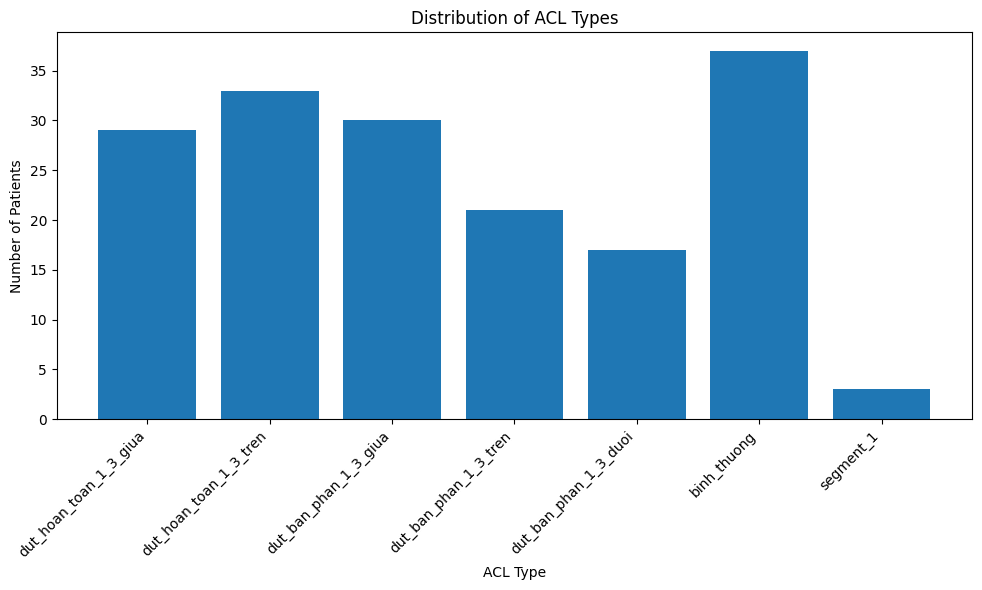

In [109]:
def get_acl_indices(seg_header: dict):
    seg_indices = []
    for k in seg_header.keys():
        m = pattern.match(k)
        if m:
            seg_indices.append(m.group(1))
    return seg_indices

def get_acl_type(seg_header: Dict):
    indices = get_acl_indices(seg_header=seg_header)
    for idx in indices:
        tag_key = f"Segment{idx}_Tags"
        name_key = f"Segment{idx}_Name"
        if tag_key in seg_header and name_key in seg_header:
            v = str(seg_header[tag_key])
            if v.startswith(Segment_signal_string):
                return str(seg_header[name_key]).lower()

def collect_data_and_seg(root_dir: str) -> Dict:
    root_dir = Path(root_dir)
    result = {}
    for subfolder in root_dir.iterdir():
        if not subfolder.is_dir():
            continue
        seg_files = sorted(subfolder.glob("Segmentation*.seg.nrrd"))
        t2_files = sorted(
            p for p in subfolder.glob("*.nrrd")
            if "t2_tse_sag" in p.stem.lower()
        )
        
        if not seg_files or not t2_files:
            continue
        _, seg_header = nrrd.read(str(seg_files[0]))
        acl_type = get_acl_type(seg_header=seg_header)
        result[subfolder.name] = {
            "nrrd": str(t2_files[0]),
            "seg": str(seg_files[0]),
            "type": acl_type
        }
    return result

if __name__ =="__main__":
    root_dir=Path("D:\personal_data\Duy Phan Ig\my_tool\data")
    # root_dir=Path("D:\Project\ACL\my_tool\data")
    all_patients = {}
    for sub_folder in root_dir.iterdir():
        if not sub_folder.is_dir():
            continue
        print(sub_folder.name)
        data_dict = collect_data_and_seg(sub_folder)
        all_patients.update(data_dict)

        print(f"number of selected files: {len(data_dict)}")
        # for patient, data in data_dict.items():
        #     print(f"Patient {patient} with ACL type: {data['type']}")
    
    type_count = {}
    for patient, data in all_patients.items():
        acl_type = data["type"]
        if acl_type is None:
            acl_type = "unknown"
        if acl_type in type_count:
            type_count[acl_type] += 1
        else:
            type_count[acl_type] = 1

    print("\nACL type distribution:")
    print(f"Total patient: {len(all_patients)}")
    for k, v in type_count.items():
        print(f"{k}: {v}")
    # =========================
    # PLOT
    # =========================
    labels = list(type_count.keys())
    counts = list(type_count.values())
    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts)
    plt.xlabel("ACL Type")
    plt.ylabel("Number of Patients")
    plt.title("Distribution of ACL Types")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [110]:
class MRI_data(Dataset):
    def __init__(self,data_dict:Dict,img_trasform=None,label_transform=None,target_size=(320,320)):
        self.data_dict=data_dict
        self.img_transform=img_trasform
        self.label_transform=label_transform
        self.target_size=target_size
        self.samples=[]
        Num_patient=0
        for patient, data in data_dict.items():
            nrrd_path=data['nrrd']
            seg_path=data['seg']
            nrrd_data,nrrd_header=nrrd.read(nrrd_path)
            seg_data,seg_header=nrrd.read(seg_path)
            type_acl=data['type']
            if type_acl=='segment_1':
                print(f"Skipping segment_1 label")
                continue
            if nrrd_data.shape != seg_data.shape:
                print(f"Mismatch shape for {patient}: image={nrrd_data.shape}, seg={seg_data.shape}")
                continue
            depth=nrrd_data.shape[2]
            for i in range(depth):
                img_slice=nrrd_data[:,:,i].astype(np.float32)
                seg_slice=seg_data[:,:,i]
                if np.any(seg_slice):
                    label = label_type[type_acl]
                else:
                    label = 0
                self.samples.append((img_slice,label)) 
            Num_patient+=1
        print(f"Number of patient selected/ Number of patient: {Num_patient}/{len(data_dict)}")
    def __len__(self):
        return len(self.samples)
     
    def __getitem__(self, index): 
        img,label=self.samples[index]
        img=img/np.max(img)                         # Normalize to [0,1]
        img=torch.tensor(img,dtype=torch.float32)   # Convert to tensor
        img=img.unsqueeze(0)                        # Add channel dimension
        label=torch.tensor(label,dtype=torch.long)  # Convert label to tensor
        if self.img_transform:
            img=self.img_transform(img)
        if self.label_transform:
            label=self.label_transform(label)
        return img,label 

In [111]:
img_transform=transforms.Compose([
    transforms.CenterCrop((320,320)),
])


In [112]:
dataset=MRI_data(data_dict=all_patients,img_trasform=img_transform)
print(f"Dataset length: {len(dataset)}")
print(f"Sample image shape: {dataset[39][0].shape}, Sample label: {dataset[39][1]}")



Mismatch shape for BUI NGUYEN BAO QUOC (18024987): image=(608, 608, 25), seg=(544, 544, 29)
Mismatch shape for MAI THI BICH LOC (25073019): image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for TRUONG THI BAO NGOC 25111764: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Cai Kim Loc_25210566: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Le Thi Thuy_25193052: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Le Van Chung_25938957: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Hoang Gia Tuan_20250616: image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Nguyen Huu Nghia_25246508: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Minh Luan_24281378: image=(352, 352, 25), seg=(320, 320, 29)
Mismatch shape for Nguyen Ngoc Dang Duong_20250529 (loi ve): image=(608, 608, 25), seg=(512, 512, 29)
Mismatch shape for Nguyen Ngoc Long_20250911: image=(352, 352, 23), seg=(320, 320, 27)
Mismatch shape for Nguyen T

In [113]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 2391
Validation set size: 598


Overall Dataset Label Distribution:


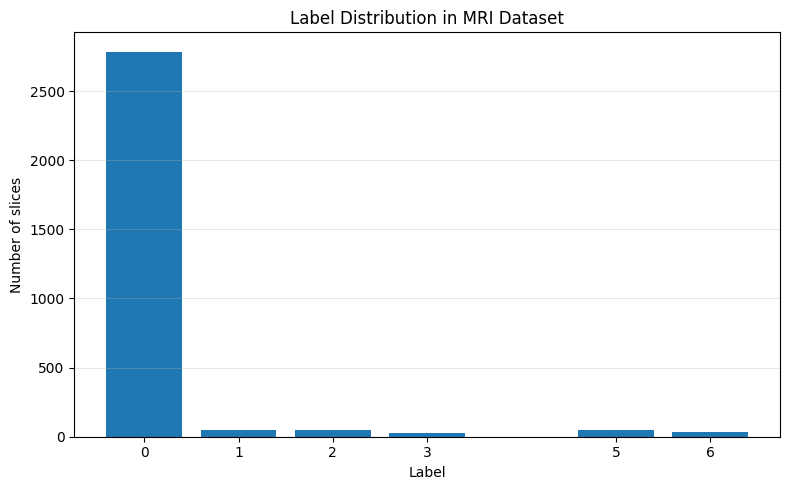

Label 0: 2786 samples
Label 1: 47 samples
Label 2: 46 samples
Label 3: 27 samples
Label 5: 47 samples
Label 6: 36 samples
Training Set Label Distribution:


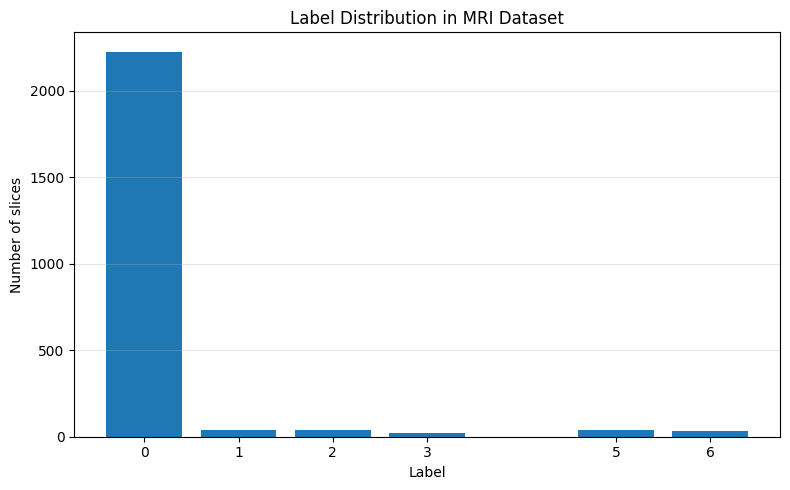

Label 0: 2225 samples
Label 1: 38 samples
Label 2: 38 samples
Label 3: 20 samples
Label 5: 38 samples
Label 6: 32 samples
Validation Set Label Distribution:


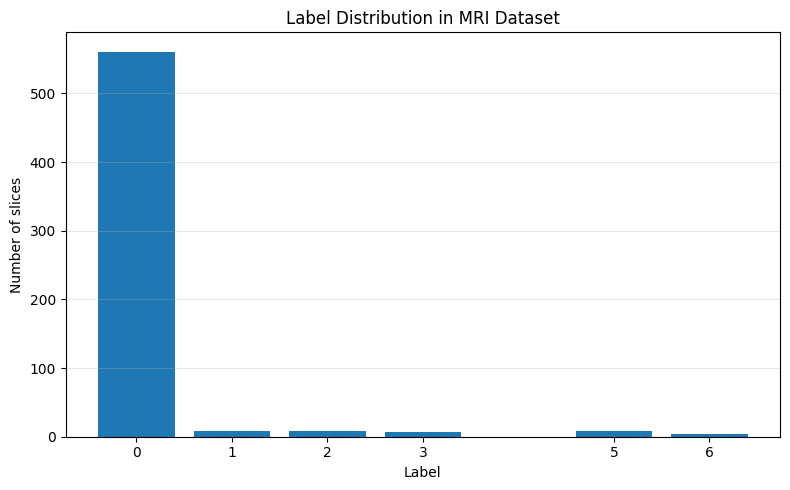

Label 0: 561 samples
Label 1: 9 samples
Label 2: 8 samples
Label 3: 7 samples
Label 5: 9 samples
Label 6: 4 samples


In [114]:
def plot_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        # handle torch tensor labels
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)
    label_counts = Counter(labels)
    # sort by label index
    labels_sorted = sorted(label_counts.keys())
    counts_sorted = [label_counts[l] for l in labels_sorted]
    plt.figure(figsize=(8, 5))
    plt.bar(labels_sorted, counts_sorted)
    plt.xlabel("Label")
    plt.ylabel("Number of slices")
    plt.title("Label Distribution in MRI Dataset")
    plt.xticks(labels_sorted)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    # also print counts
    for l in labels_sorted:
        print(f"Label {l}: {label_counts[l]} samples")
# Plot label distribution for the entire dataset, training set, and validation set
print("Overall Dataset Label Distribution:")
plot_label_distribution(dataset)
print("Training Set Label Distribution:")
plot_label_distribution(train_dataset)
print("Validation Set Label Distribution:")
plot_label_distribution(val_dataset)

In [115]:
target=[]
for _, label in train_dataset:
    if isinstance(label, torch.Tensor):
        label = label.item()
    target.append(label)
target=torch.tensor(target,dtype=torch.long)
# 1) unique classes
classes = torch.unique(target, sorted=True)
print(f"Unique classes in training set: {classes}")
# 2) mapping: label → index
class_to_index = {int(c): i for i, c in enumerate(classes)}
# 3) count samples per class
class_samples_count = torch.tensor([
    (target == c).sum() for c in classes
], dtype=torch.float)
# 4) class weights
weight = 1.0 / class_samples_count
# 5) sample weights (SAFE)
samples_weight = torch.tensor(
    [weight[class_to_index[int(t)]] for t in target],
    dtype=torch.float
)
# 6) sampler
sampler = torch.utils.data.WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

Unique classes in training set: tensor([0, 1, 2, 3, 5, 6])


In [116]:
train_loader = DataLoader(train_dataset,batch_size=16,sampler=sampler,shuffle=False)
val_loader = DataLoader(val_dataset,batch_size=16,shuffle=True)

In [117]:
wandb.login()

True

In [118]:
ARCH={
    'cnn1':
    {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':3,
        'number_of_fc_layer':2,
        'num_classes':7,
        'conv_channels': [6, 16,24],
        'fc_feature':[104,7]
    },
    'cnn2':
    {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':4,
        'number_of_fc_layer':3,
        'num_classes':7,
        'conv_channels': [6, 16,24,32],
        'fc_feature':[104,64,7]
    }
}

In [119]:
class TrainerWB: 
    def __init__(self,config,train_loader,val_loader): 
        self.config=config
        self.device=torch.device('cuda' if torch.cuda.is_available() else'cpu')
        self.epochs=config.epoch
        self.learning_rate=config.lr
        self.batch_size=config.batch_size

        self.train_loader=train_loader
        self.val_loader=val_loader

        para=ARCH[config.architecture]
        self.model=LeNet(para).to(self.device)

        self.criterion=nn.CrossEntropyLoss()
        self.optimizer=self.optim_build()

        wandb.config.update({"model_para": para}, allow_val_change=True)

    def optim_build(self): 
        if self.config['optim']=='SGD': 
            return optim.SGD(self.model.parameters(), lr=self.learning_rate, momentum=0.9) 
        elif self.config['optim']=='Adam': 
            return optim.Adam(self.model.parameters(), lr=self.learning_rate) 
        else: 
            raise ValueError("Unsupported optimizer type") 
    def train(self): 
        self.model.train()
        running_loss=0.0 
        correct=9 
        total=0 
        loop=tqdm(self.train_loader,desc='Tao dang training',leave=False) 
        for image, label in loop: 
            image,label= image.to(self.device), label.to(self.device) 
            #Forward propagation: 
            output=self.model(image) 
            loss=self.criterion(output,label) 
            #backward propagation 
            self.optimizer.zero_grad() 
            loss.backward() 
            self.optimizer.step() 
            #Metrics calculation 
            running_loss += loss.item() 
            preds=torch.argmax(output,dim=1) 
            correct += (preds==label).sum().item() 
            total += label.size(0)
             #Update progress bar 
            loop.set_postfix(loss=running_loss/ (total/self.batch_size), accuracy=100.* correct/ total) 
        avg_loss = running_loss / total 
        accuracy = correct / total 
        return avg_loss, accuracy 
    def validate(self): 
        self.model.eval() 
        running_loss = 0.0 
        correct = 0 
        total = 0 
        with torch.no_grad(): 
            for images, labels in self.val_loader: 
                images, labels = images.to(self.device), labels.to(self.device) 
                outputs = self.model(images) 
                loss = self.criterion(outputs, labels) 
                running_loss += loss.item() * images.size(0) 
                preds = torch.argmax(outputs, dim=1) 
                correct += (preds == labels).sum().item() 
                total += labels.size(0) 
            avg_loss = running_loss / total 
            accuracy = correct / total 
        return avg_loss, accuracy 
    def fit(self): 
        for epoch in range(self.epochs): 
            train_loss, train_acc = self.train() 
            val_loss, val_acc = self.validate() 
            print(f"Epoch [{epoch+1}/{self.epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}") 
            wandb.log({ "Train Loss": train_loss, 
                        "Train Accuracy": train_acc, 
                        "Validation Loss": val_loss, 
                        "Validation Accuracy": val_acc }) 
            print("Training complete.")

In [120]:
def main():
    with wandb.init(project="ACL_Classification", reinit=True):
        trainer = TrainerWB(
            config=wandb.config,
            train_loader=train_loader,
            val_loader=val_loader
        )
        trainer.fit()

In [121]:
sweep_config={
    'method':'random',
    'metric':{
        'name':'Validation Accuracy',
        'goal':'maximize'
    },
    'parameters':{
        'lr':{
            'values':[0.01,0.001,0.0001]
        },
        'epoch':{
            'values':[50,60,70]
        },
        'batch_size':{
            'values':[2,4,8,16]
        },
        'optim':{
            'values':['SGD']
        },
        'architecture':{
            'values':['cnn1','cnn2']
        }
    }
}


In [ ]:
sweep_id= wandb.sweep(sweep_config, project="ACL_Classification")
wandb.agent(sweep_id, function=main, count=10)

Create sweep with ID: 9fqfvdhn
Sweep URL: https://wandb.ai/baymaxnguyen306-ho-chi-minh-city-university-of-technology/ACL_Classification/sweeps/9fqfvdhn


wandb: Agent Starting Run: rczsrjio with config:
wandb: 	architecture: cnn2
wandb: 	batch_size: 2
wandb: 	epoch: 50
wandb: 	lr: 0.0001
wandb: 	optim: SGD


Epoch [1/50], Train Loss: 0.2607, Train Acc: 0.0071, Val Loss: 4.1572, Val Acc: 0.0017
Training complete.


Epoch [2/50], Train Loss: 0.2599, Train Acc: 0.1205, Val Loss: 4.1572, Val Acc: 0.0134
Training complete.


Epoch [3/50], Train Loss: 0.2557, Train Acc: 0.1690, Val Loss: 4.1609, Val Acc: 0.0134
Training complete.


...

Epoch [34/70], Train Loss: 0.0749, Train Acc: 0.9816, Val Loss: 1.2509, Val Acc: 0.9281
Training complete.


Epoch [35/70], Train Loss: 0.0747, Train Acc: 0.9854, Val Loss: 1.2516, Val Acc: 0.9314
Training complete.


Epoch [36/70], Train Loss: 0.0751, Train Acc: 0.9791, Val Loss: 1.2488, Val Acc: 0.9281
Training complete.


Epoch [37/70], Train Loss: 0.0750, Train Acc: 0.9808, Val Loss: 1.2451, Val Acc: 0.9247
Training complete.


Tao dang training:  79%|███████▉  | 119/150 [00:01<00:00, 67.54it/s, accuracy=98.5, loss=0.596]